<a href="https://colab.research.google.com/github/lakka18/TUGAS-PROYEK-SISTEM-PENGONTROL-KETINGGIAN-AIR-MENGGUNAKAN-PID/blob/main/Poop_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.0 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import os
from google.colab import drive

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import files
print("Upload your dataset zip file:")
uploaded = files.upload()

Upload your dataset zip file:


In [ ]:
import zipfile
for filename in uploaded.keys():
    print(f"Extracting {filename}...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')

Extracting Poop.v4-flat.yolov8.zip...


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="3zBfdippTa5Hp7obLb0x")
project = rf.workspace("lakka").project("poop-version-2-lsemy")
version = project.version(1)
dataset = version.download("yolov8")
print(f"✓ Dataset downloaded to: {dataset.location}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 116.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Poop-version-2-1 in yolov8:: 100%|██████████| 1042/1042 [00:00<00:00, 7520.20it/s]

✓ Dataset downloaded to: /content/Poop-version-2-1


In [5]:
print("\nDataset contents:")
!ls -la /content/Poop-version-2-1


Dataset contents:
total 32
drwxr-xr-x 5 root root 4096 Nov  6 04:47 .
drwxr-xr-x 1 root root 4096 Nov  6 04:47 ..
-rw-r--r-- 1 root root  254 Nov  6 04:47 data.yaml
-rw-r--r-- 1 root root  144 Nov  6 04:47 README.dataset.txt
-rw-r--r-- 1 root root 1216 Nov  6 04:47 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Nov  6 04:47 test
drwxr-xr-x 4 root root 4096 Nov  6 04:47 train
drwxr-xr-x 4 root root 4096 Nov  6 04:47 valid


In [6]:
print("\nDataset contents:")
if 'dataset' in locals():
    # If using Roboflow API
    !ls -la {dataset.location}
    DATASET_PATH = f'{dataset.location}/data.yaml'
else:
    # If uploaded manually
    !ls -la /content/dataset
    DATASET_PATH = '/content/dataset/data.yaml'

print(f"\nUsing dataset at: {DATASET_PATH}")


Dataset contents:
total 32
drwxr-xr-x 5 root root 4096 Nov  6 04:47 .
drwxr-xr-x 1 root root 4096 Nov  6 04:47 ..
-rw-r--r-- 1 root root  254 Nov  6 04:47 data.yaml
-rw-r--r-- 1 root root  144 Nov  6 04:47 README.dataset.txt
-rw-r--r-- 1 root root 1216 Nov  6 04:47 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Nov  6 04:47 test
drwxr-xr-x 4 root root 4096 Nov  6 04:47 train
drwxr-xr-x 4 root root 4096 Nov  6 04:47 valid

Using dataset at: /content/Poop-version-2-1/data.yaml


In [7]:
print("\nOriginal data.yaml contents:")
!cat {DATASET_PATH}

# Only do train/val split if needed (Roboflow usually includes validation set)
import os
import yaml

with open(DATASET_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

# Check if validation set exists
dataset_dir = os.path.dirname(DATASET_PATH)
has_valid = os.path.exists(os.path.join(dataset_dir, 'valid')) or \
            os.path.exists(os.path.join(dataset_dir, 'val'))

if not has_valid:
    print("\n⚠️ No validation set found. Creating split...")
    # Run the split code (same as before)
    from sklearn.model_selection import train_test_split
    import shutil

    train_images_path = os.path.join(dataset_dir, 'train/images')
    train_labels_path = os.path.join(dataset_dir, 'train/labels')

    image_files = [f for f in os.listdir(train_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Total images in train: {len(image_files)}")

    train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42)
    print(f"Split: {len(train_imgs)} train, {len(val_imgs)} validation")

    os.makedirs(os.path.join(dataset_dir, 'valid/images'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'valid/labels'), exist_ok=True)

    for img_name in val_imgs:
        src_img = os.path.join(train_images_path, img_name)
        dst_img = os.path.join(dataset_dir, 'valid/images', img_name)
        shutil.move(src_img, dst_img)

        label_name = os.path.splitext(img_name)[0] + '.txt'
        src_label = os.path.join(train_labels_path, label_name)
        dst_label = os.path.join(dataset_dir, 'valid/labels', label_name)
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)

    print("✓ Validation set created!")

    # Update data.yaml
    data_config['val'] = 'valid/images'
    with open(DATASET_PATH, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)
else:
    print("✓ Validation set already exists!")

print("\nFinal data.yaml:")
!cat {DATASET_PATH}



Original data.yaml contents:
names:
- poop
nc: 1
roboflow:
  license: CC BY 4.0
  project: poop-version-2-lsemy
  url: https://universe.roboflow.com/lakka/poop-version-2-lsemy/dataset/1
  version: 1
  workspace: lakka
test: ../test/images
train: ../train/images
val: ../valid/images
✓ Validation set already exists!

Final data.yaml:
names:
- poop
nc: 1
roboflow:
  license: CC BY 4.0
  project: poop-version-2-lsemy
  url: https://universe.roboflow.com/lakka/poop-version-2-lsemy/dataset/1
  version: 1
  workspace: lakka
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
# Step 6b: Fix the data.yaml paths if needed
import yaml

# Read the original data.yaml
with open('/content/dataset/data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)

print("\nOriginal config:")
print(data_config)

# Check what folders actually exist
print("\nActual folders in dataset:")
!ls -la /content/dataset/

# Update paths to absolute paths
data_config['path'] = '/content/dataset'
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images'

# If 'test' exists in config but folder doesn't exist, remove it
if 'test' in data_config:
    import os
    if not os.path.exists('/content/dataset/test'):
        del data_config['test']

# Save the updated data.yaml
with open('/content/dataset/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("\nUpdated data.yaml:")
!cat /content/dataset/data.yaml

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/data.yaml'

In [ ]:
model = YOLO('yolov8n.pt')

In [9]:
# Step 8: Train the model
# Training Configuration for Multi-Distance Poop Detection
# Solves the "close-up only" problem with aggressive augmentation

from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load model
model = YOLO('yolov8s.pt')
if device == 'cpu':
    print("⚠️ WARNING: Training on CPU will be VERY slow!")
    print("Enable GPU: Runtime → Change runtime type → T4 GPU")


results = model.train(
    data=f'{dataset.location}/data.yaml' ,

    # ===== Basic Settings =====
    epochs=80,
    batch=16,
    imgsz=640,
    patience=70,
    device=device,

    # ===== AGGRESSIVE SCALING AUGMENTATION =====
    # This is the KEY to detecting poop at different distances!
    scale=0.9,              # Scale images 10-190% (default is 0.5)
                            # This makes close-up poop appear far away

    # ===== MOSAIC AUGMENTATION =====
    # Combines 4 images - creates scenes with poop at different scales
    mosaic=1.0,             # Use mosaic 100% of the time

    # ===== MULTI-SCALE TRAINING =====
    # Train on different image sizes to learn scale invariance
    multi_scale=True,       # Randomly resize images ±50% during training

    # ===== COPY-PASTE AUGMENTATION =====
    # Pastes poop objects at different sizes/locations
    copy_paste=0.3,         # 30% chance to copy-paste objects

    # ===== PERSPECTIVE & TRANSLATION =====
    perspective=0.0003,     # Slight perspective warp (simulates camera angle)
    translate=0.2,          # 20% translation (poop in different positions)

    # ===== Other Augmentations =====
    # degrees=15.0,           # More rotation variance
    # hsv_h=0.015,
    # hsv_s=0.7,
    # hsv_v=0.4,
    # fliplr=0.5,
    # flipud=0.0,
    optimizer = 'SGD',


    # ===== Additional Settings =====
    name='poop_multiscale',
    plots=True,
    cache=False,
)

print("\n" + "="*60)
print("TRAINING COMPLETE - Multi-Scale Model Ready!")
print("="*60)
print("\nThis model should now detect poop at:")
print("  ✓ Close range (original dataset)")
print("  ✓ Medium range (scale augmentation)")
print("  ✓ Far range (mosaic + multi-scale)")
print("\nTest with images at different distances to verify!")

Using device: cuda
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Poop-version-2-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=True, name=poop_multiscale, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=70, persp

In [10]:
metrics = model.val()

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1957.7±1265.8 MB/s, size: 71.7 KB)
val: Scanning /content/Poop-version-2-1/valid/labels.cache... 32 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 59.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s
                   all         32         55      0.998      0.818      0.843      0.651
Speed: 7.6ms preprocess, 10.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val



Training completed!
Best model saved at: /content/runs/detect/poop_multiscale/weights/best.pt
Results directory: /content/runs/detect/poop_multiscale

📊 Training Results:


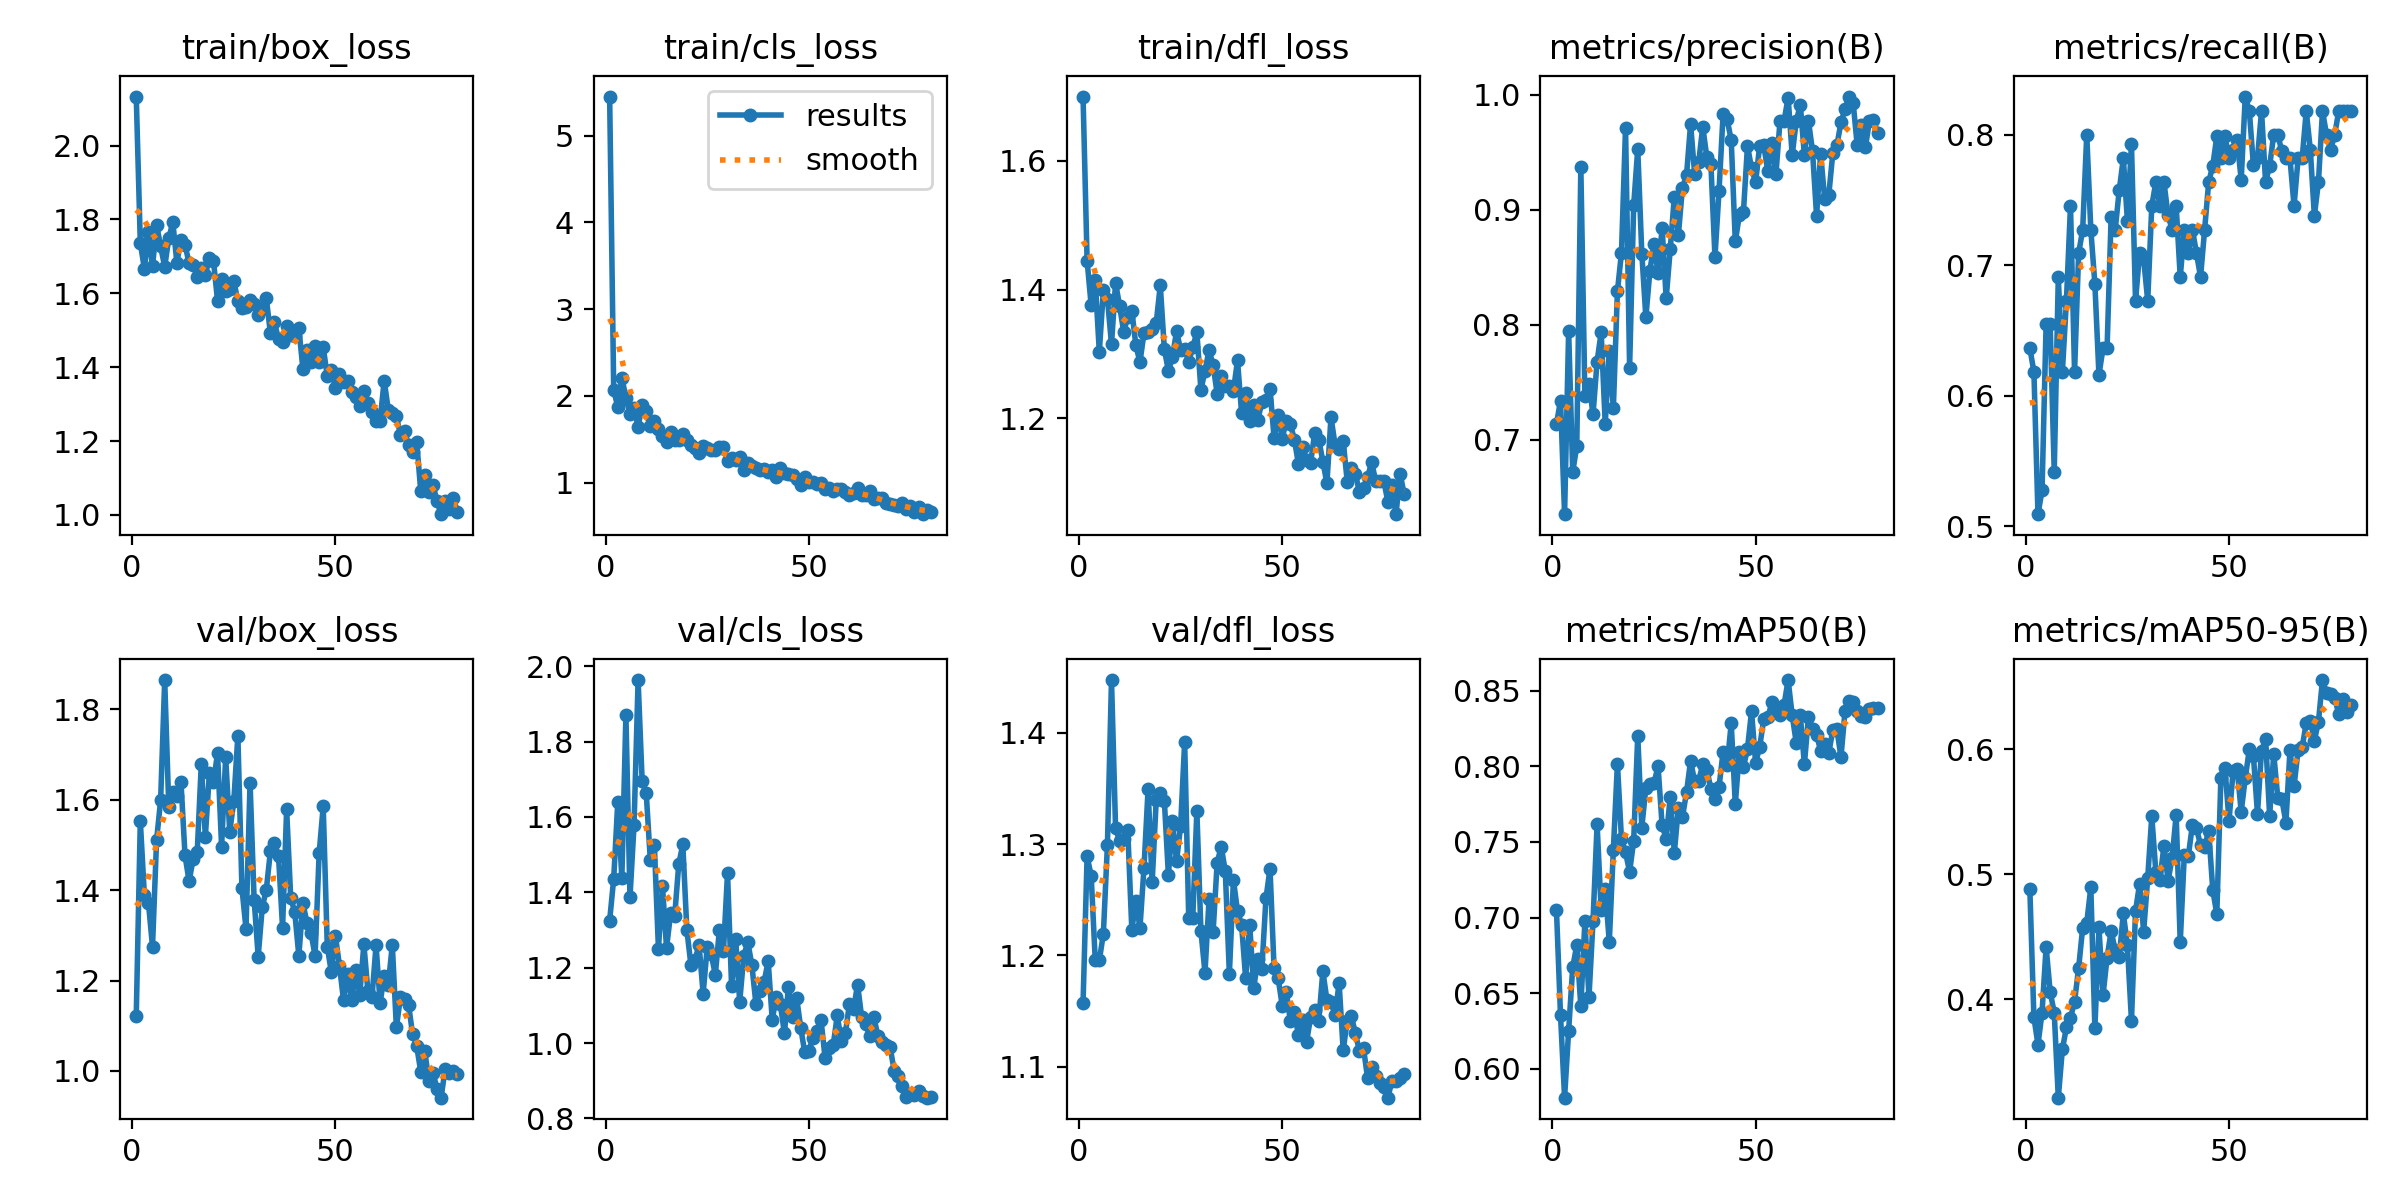


📊 Confusion Matrix:


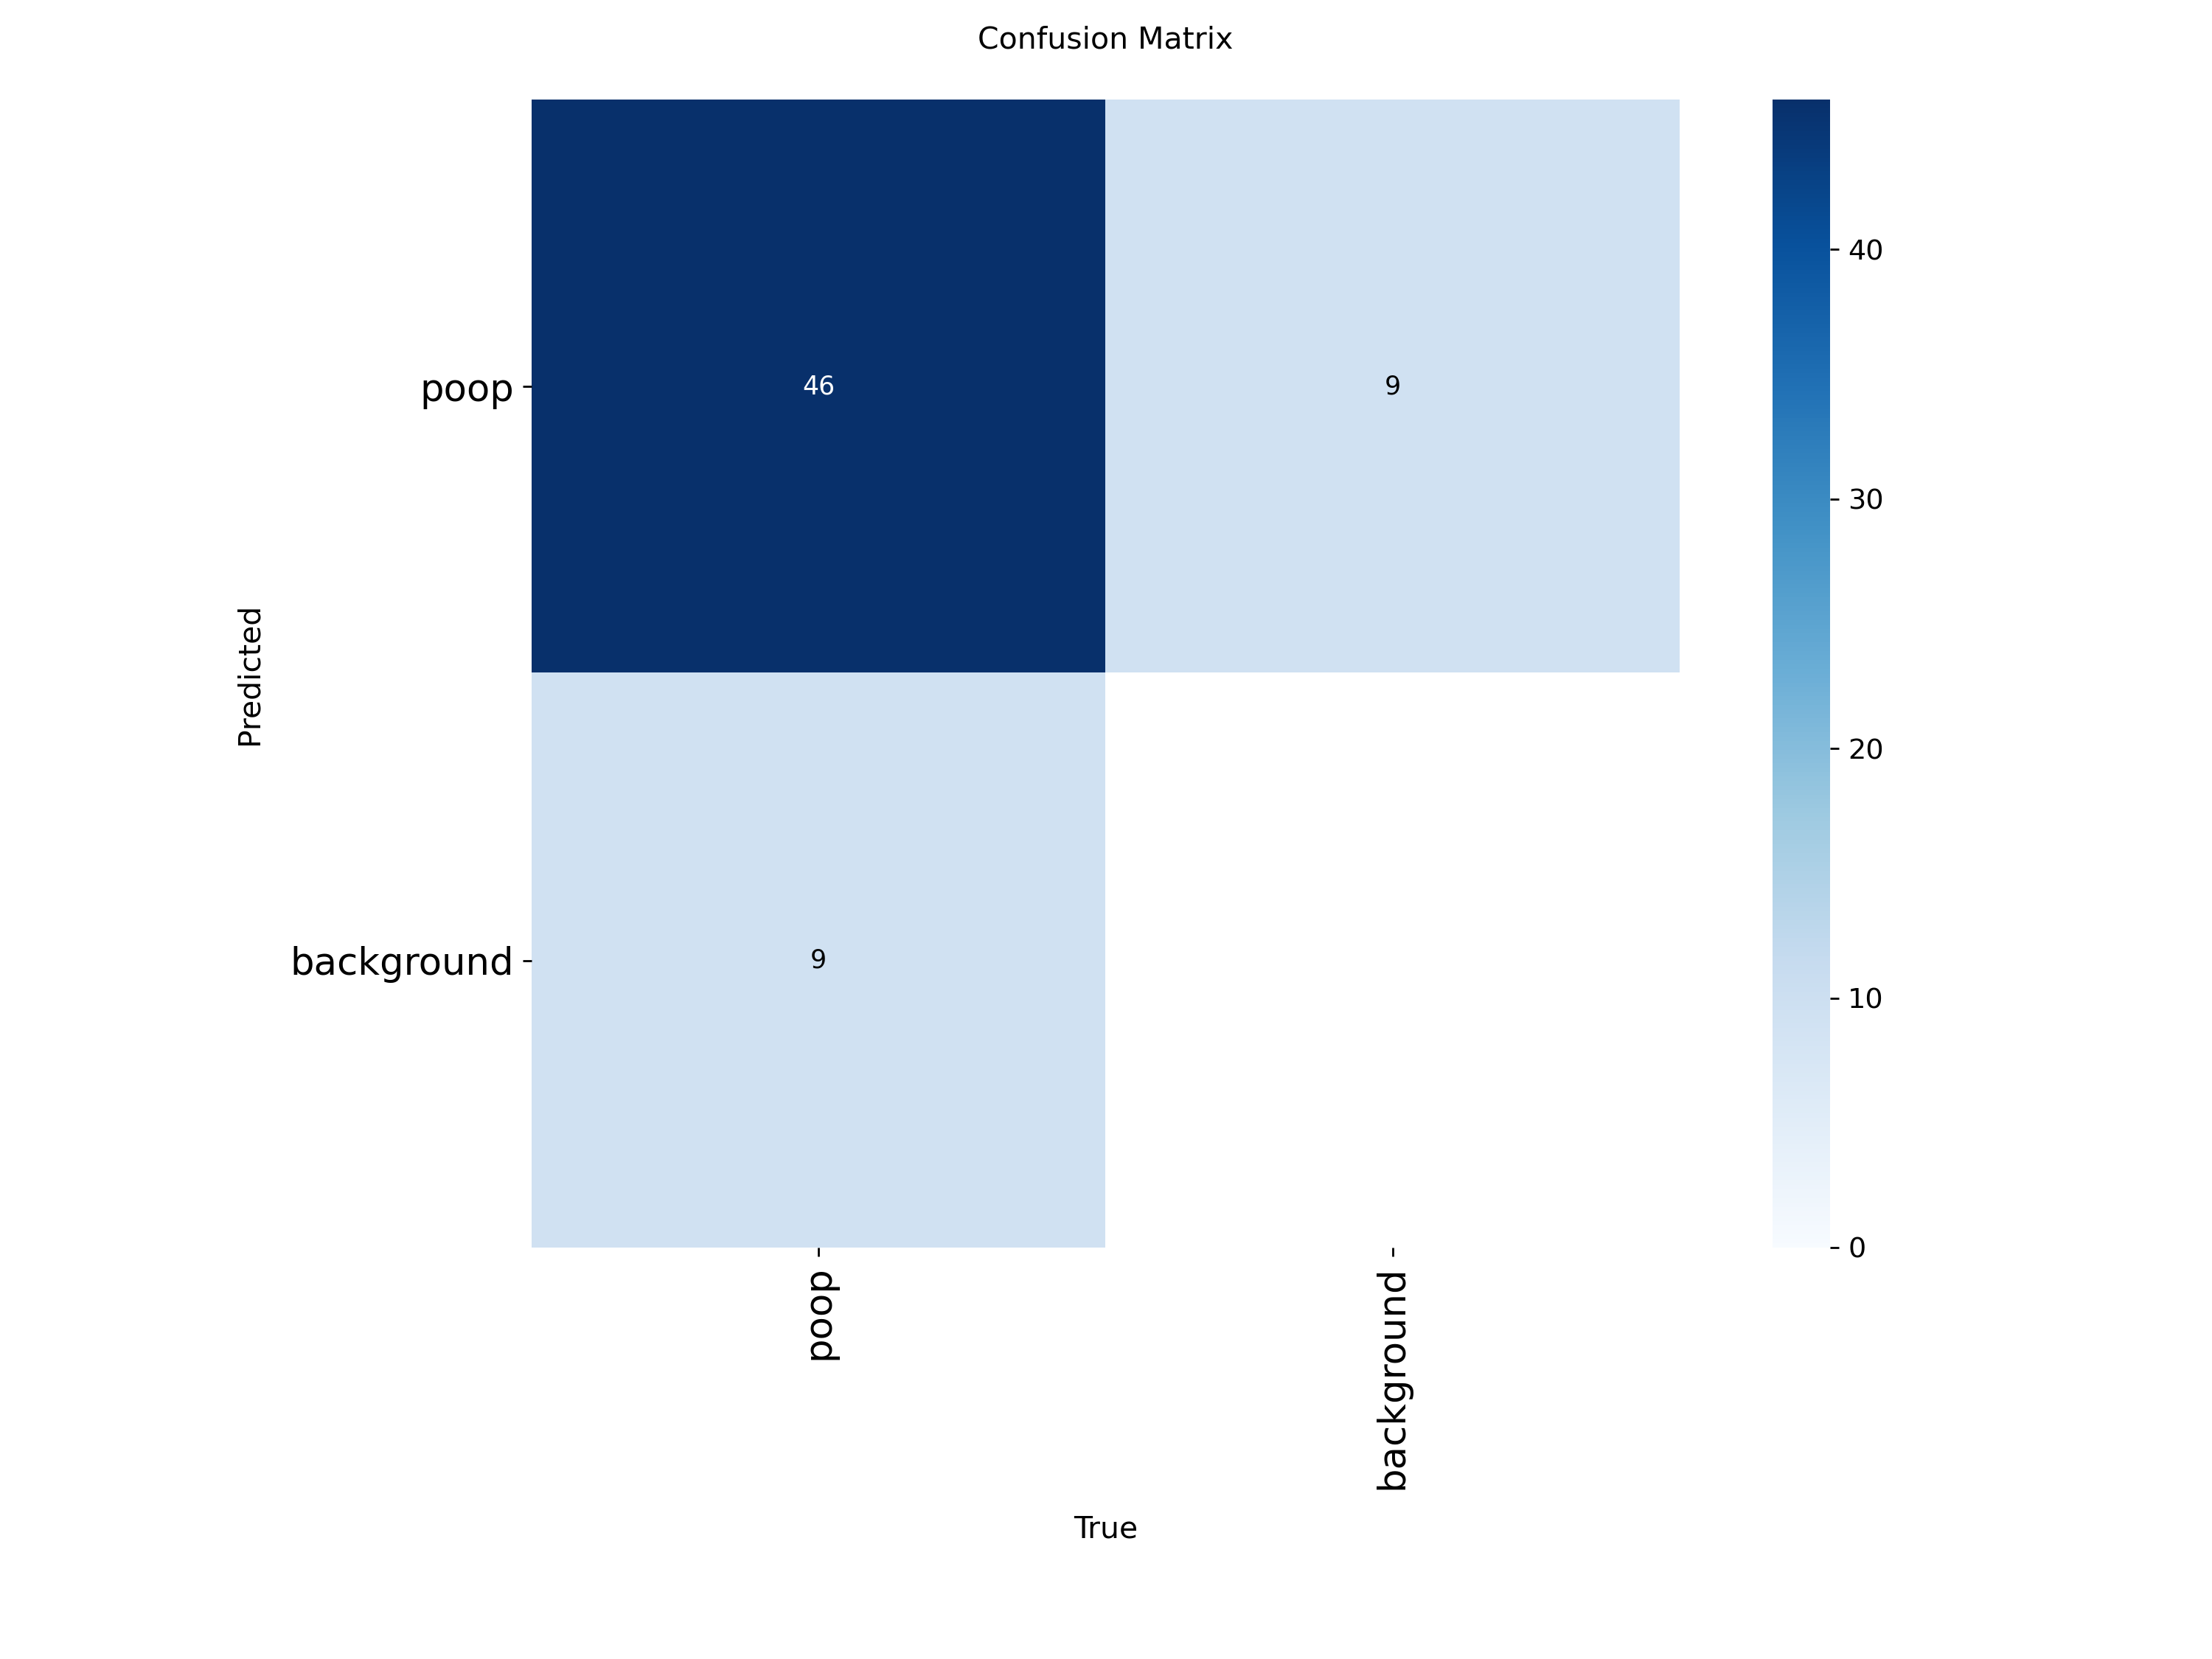

In [11]:
#Step 10: Display training results
print("\nTraining completed!")
print(f"Best model saved at: {model.trainer.best}")

# View training plots using the actual save directory
from IPython.display import Image, display
import os

save_dir = model.trainer.save_dir
print(f"Results directory: {save_dir}")

# Display results if they exist
results_file = os.path.join(save_dir, 'results.png')
confusion_file = os.path.join(save_dir, 'confusion_matrix.png')

if os.path.exists(results_file):
    print("\n📊 Training Results:")
    display(Image(filename=results_file))
else:
    print(f"Results plot not found at {results_file}")

if os.path.exists(confusion_file):
    print("\n📊 Confusion Matrix:")
    display(Image(filename=confusion_file))
else:
    print(f"Confusion matrix not found at {confusion_file}")


Upload a test image:


Saving WhatsApp Bild 2025-11-04 um 15.40.09_4c5e63a4.jpg to WhatsApp Bild 2025-11-04 um 15.40.09_4c5e63a4.jpg

image 1/1 /content/WhatsApp Bild 2025-11-04 um 15.40.09_4c5e63a4.jpg: 640x640 2 poops, 16.2ms
Speed: 4.0ms preprocess, 16.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

Predictions for WhatsApp Bild 2025-11-04 um 15.40.09_4c5e63a4.jpg:
Class: poop, Confidence: 0.81
Class: poop, Confidence: 0.45


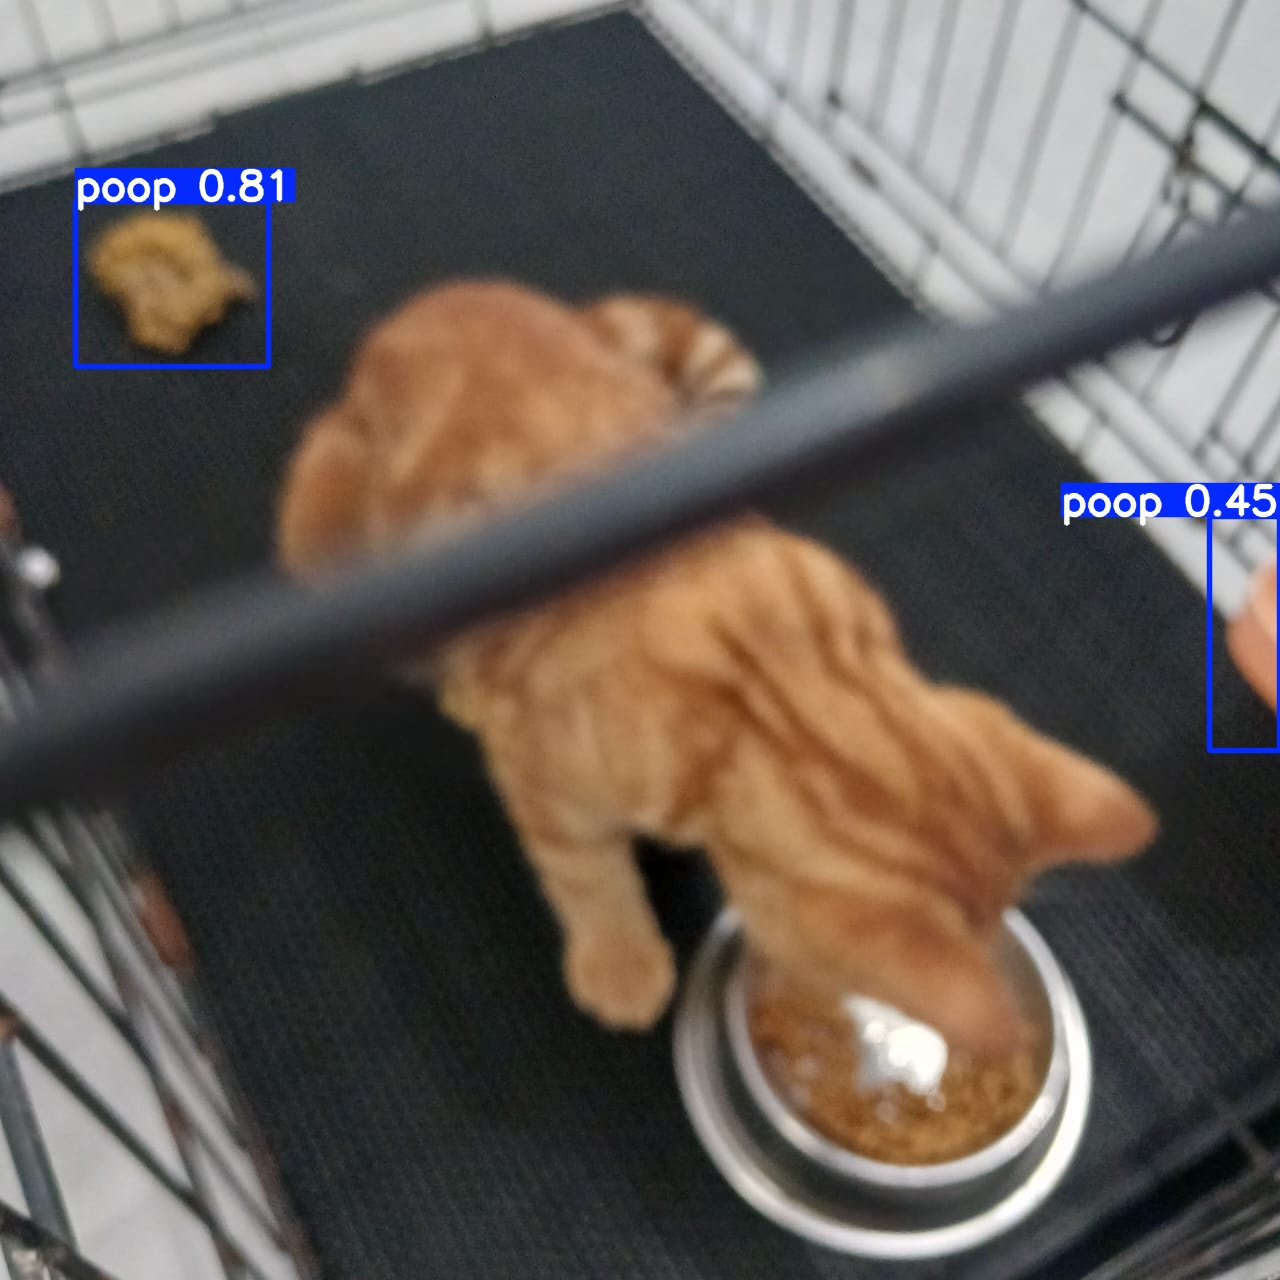

In [12]:
from google.colab import files
print("\nUpload a test image:")
test_img = files.upload()

# Run inference
for img_name in test_img.keys():
    results = model.predict(source=img_name, save=True, conf=0.25)
    print(f"\nPredictions for {img_name}:")
    for r in results:
        for box in r.boxes:
            print(f"Class: {r.names[int(box.cls)]}, Confidence: {box.conf.item():.2f}")

# Display prediction
import glob
prediction_imgs = glob.glob('/content/runs/detect/predict*/*.jpg') + glob.glob('/content/runs/detect/predict*/*.png')
if prediction_imgs:
    display(Image(filename=prediction_imgs[-1]))

In [ ]:
# Upload a test image
print("\nUpload a test image:")
test_img = files.upload()


Upload a test image:


Saving smelly-cat-litter-box.jpg to smelly-cat-litter-box (1).jpg


In [ ]:
for img_name in test_img.keys():
    results = model.predict(source=img_name, save=True, conf=0.25)
    print(f"\nPredictions for {img_name}:")
    for r in results:
        for box in r.boxes:
            print(f"Class: {r.names[int(box.cls)]}, Confidence: {box.conf.item():.2f}")



image 1/1 /content/smelly-cat-litter-box (1).jpg: 416x640 4 poops, 12.6ms
Speed: 2.1ms preprocess, 12.6ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict

Predictions for smelly-cat-litter-box (1).jpg:
Class: poop, Confidence: 0.79
Class: poop, Confidence: 0.63
Class: poop, Confidence: 0.53
Class: poop, Confidence: 0.52


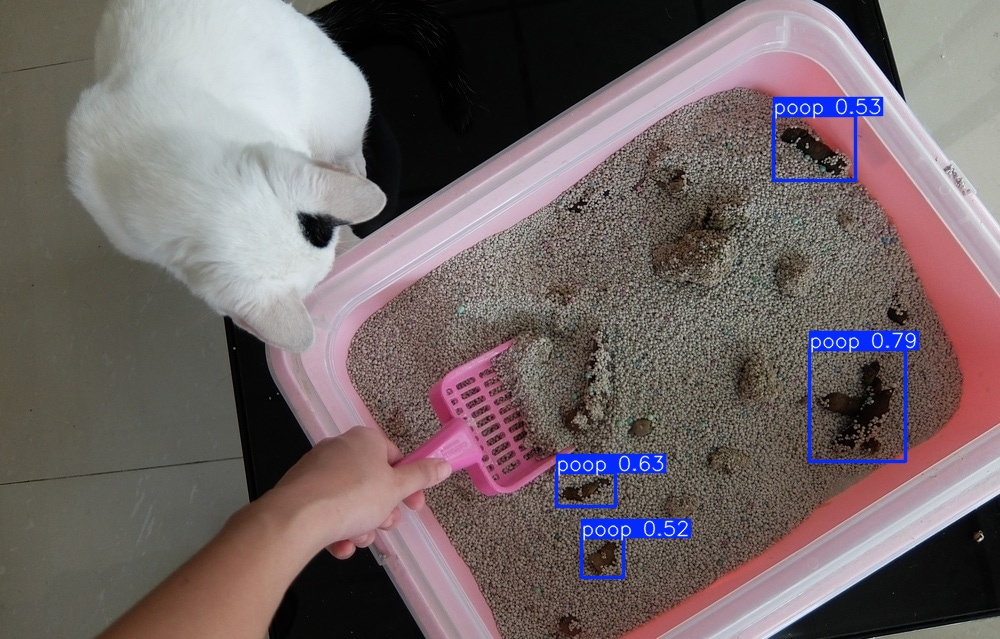

In [ ]:
import glob
prediction_imgs = glob.glob('/content/runs/detect/predict*/*.jpg') + glob.glob('/content/runs/detect/predict*/*.png')
if prediction_imgs:
    display(Image(filename=prediction_imgs[-1]))

In [13]:
# Step 12: Export the model (optional)
# Export to different formats for deployment
model.export(format='pt')  # Export to ONNX format
# Other formats: 'torchscript', 'tflite', 'saved_model', etc.

ValueError: Model is already in PyTorch format. Valid formats are ('torchscript', 'onnx', 'openvino', 'engine', 'coreml', 'saved_model', 'pb', 'tflite', 'edgetpu', 'tfjs', 'paddle', 'mnn', 'ncnn', 'imx', 'rknn', 'executorch')

In [15]:

# Step 13: Download the trained model
print("\nDownloading trained model...")
files.download(f'/content/runs/detect/poop_multiscale/weights/best.onnx')

print("\n✅ Training complete! Your model is ready to use.")
print("You can use best.pt to detect cat pooping in new images/videos.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Training complete! Your model is ready to use.
You can use best.pt to detect cat pooping in new images/videos.


In [17]:

import yaml
import os
from pathlib import Path

print("="*60)
print("TRAINING DIAGNOSTIC REPORT")
print("="*60)

# ===== 1. CHECK DATASET STRUCTURE =====
print("\n1️⃣ DATASET STRUCTURE CHECK:")
print("-" * 40)

with open(DATASET_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

dataset_dir = Path(DATASET_PATH).parent

# Count images
train_dir = dataset_dir / data_config.get('train', 'train/images')
val_dir = dataset_dir / data_config.get('val', 'valid/images')

train_images = list(train_dir.glob('*.jpg')) + list(train_dir.glob('*.png'))
val_images = list(val_dir.glob('*.jpg')) + list(val_dir.glob('*.png'))

print(f"Training images:   {len(train_images)}")
print(f"Validation images: {len(val_images)}")
print(f"Total images:      {len(train_images) + len(val_images)}")
print(f"Split ratio:       {len(train_images)/(len(train_images)+len(val_images))*100:.1f}% train")

# Check if split was modified
if len(val_images) / (len(train_images) + len(val_images)) == 0.2:
    print("⚠️ WARNING: This looks like an 80/20 split created by the script!")
    print("   This is DIFFERENT from Roboflow's original split!")
    print("   Solution: Re-download dataset from Roboflow")
else:
    print("✓ Using Roboflow's original split")

# ===== 2. CHECK TRAINING HISTORY =====
print("\n2️⃣ TRAINING HISTORY CHECK:")
print("-" * 40)

# Find most recent training run
runs_dir = Path('/content/runs/detect')
if runs_dir.exists():
    training_runs = sorted(runs_dir.glob('*'), key=os.path.getmtime, reverse=True)
    if training_runs:
        latest_run = training_runs[0]
        print(f"Latest training: {latest_run.name}")

        # Check if training completed
        results_csv = latest_run / 'results.csv'
        if results_csv.exists():
            import pandas as pd
            df = pd.read_csv(results_csv)

            epochs_completed = len(df)
            print(f"Epochs completed: {epochs_completed}")

            # Check if early stopping triggered
            best_epoch = df['metrics/mAP50(B)'].idxmax()
            print(f"Best epoch: {best_epoch + 1}")

            if epochs_completed < 100:
                print("⚠️ WARNING: Training stopped very early!")
                print("   Reason: Likely due to patience setting")
                print("   Solution: Increase patience to 100+")
            elif epochs_completed - best_epoch > 50:
                print("✓ Training continued for 50 epochs after best")
                print("  (Early stopping worked correctly)")

            # Show final metrics
            final_metrics = df.iloc[-1]
            print(f"\nFinal Training Metrics:")
            print(f"  train/box_loss:  {final_metrics.get('train/box_loss', 'N/A'):.4f}")
            print(f"  train/cls_loss:  {final_metrics.get('train/cls_loss', 'N/A'):.4f}")
            print(f"  val/box_loss:    {final_metrics.get('val/box_loss', 'N/A'):.4f}")
            print(f"  val/cls_loss:    {final_metrics.get('val/cls_loss', 'N/A'):.4f}")
            print(f"  mAP50:           {final_metrics.get('metrics/mAP50(B)', 0):.4f}")
            print(f"  Precision:       {final_metrics.get('metrics/precision(B)', 0):.4f}")
            print(f"  Recall:          {final_metrics.get('metrics/recall(B)', 0):.4f}")

            # Check for overfitting
            train_loss = final_metrics.get('train/box_loss', 0)
            val_loss = final_metrics.get('val/box_loss', 0)

            if val_loss > train_loss * 1.5:
                print("\n⚠️ WARNING: Possible OVERFITTING detected!")
                print(f"   Val loss ({val_loss:.4f}) >> Train loss ({train_loss:.4f})")
                print("   Solution: Increase augmentation or add more data")
            elif train_loss > val_loss:
                print("\n⚠️ WARNING: Possible UNDERFITTING detected!")
                print(f"   Train loss ({train_loss:.4f}) > Val loss ({val_loss:.4f})")
                print("   Solution: Train longer or use larger model")
            else:
                print("\n✓ No obvious overfitting/underfitting")
        else:
            print("❌ No results.csv found!")
    else:
        print("❌ No training runs found!")
else:
    print("❌ Runs directory not found!")

# ===== 3. CHECK MODEL CONFIGURATION =====
print("\n3️⃣ MODEL CONFIGURATION:")
print("-" * 40)

# Check which model was used
if 'model' in globals():
    print(f"Model: {model.model_name}")
    print(f"Parameters: ~{sum(p.numel() for p in model.model.parameters())/1e6:.1f}M")
else:
    print("⚠️ Model not loaded")

# ===== 4. COMPARE WITH ROBOFLOW =====
print("\n4️⃣ PERFORMANCE COMPARISON:")
print("-" * 40)

print("Roboflow Results:")
print("  mAP50:     87.4%")
print("  Precision: 95.5%")
print("  Recall:    83.6%")

if 'results_csv' in locals() and results_csv.exists():
    current_map50 = final_metrics.get('metrics/mAP50(B)', 0) * 100
    current_precision = final_metrics.get('metrics/precision(B)', 0) * 100
    current_recall = final_metrics.get('metrics/recall(B)', 0) * 100

    print(f"\nCurrent Results:")
    print(f"  mAP50:     {current_map50:.1f}%")
    print(f"  Precision: {current_precision:.1f}%")
    print(f"  Recall:    {current_recall:.1f}%")

    print(f"\nDifference:")
    print(f"  mAP50:     {current_map50 - 87.4:+.1f}%")
    print(f"  Precision: {current_precision - 95.5:+.1f}%")
    print(f"  Recall:    {current_recall - 83.6:+.1f}%")

# ===== 5. RECOMMENDATIONS =====
print("\n5️⃣ RECOMMENDATIONS:")
print("-" * 40)

recommendations = []

if len(val_images) / (len(train_images) + len(val_images)) == 0.2:
    recommendations.append("Re-download dataset from Roboflow (don't modify split)")

if 'epochs_completed' in locals() and epochs_completed < 100:
    recommendations.append("Train for more epochs (200+) with higher patience")

if 'current_recall' in locals() and current_recall < 70:
    recommendations.append("Low recall: Increase training epochs or reduce confidence threshold")

if 'current_precision' in locals() and current_precision < 90:
    recommendations.append("Low precision: Check dataset labels for errors")

if not recommendations:
    recommendations.append("Try using yolov8m.pt (larger model)")
    recommendations.append("Increase epochs to 300")
    recommendations.append("Use SGD optimizer instead of AdamW")

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

TRAINING DIAGNOSTIC REPORT

1️⃣ DATASET STRUCTURE CHECK:
----------------------------------------
Training images:   0
Validation images: 0
Total images:      0


ZeroDivisionError: division by zero